Linear Models
====

Find patterns in the completion rate

In [3]:
"""
Create a dataframe that we'll fit to

"""

from analysis_utils import clean

meal_info = clean.cleaned_smartwatch(keep_catchups=False, keep_day0=False)

/home/mh19137/seaco_smartwatch_paper/analysis_utils/clean.py:156: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Normal' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  copy.loc[start_time, col_name] = "Normal"
/home/mh19137/seaco_smartwatch_paper/analysis_utils/clean.py:227: UserWarning: Long catchup: not marking Meal at 2022-05-19 09:02:49 as catchup
  warnings.warn(


 Open ended catchup at 2022-02-11 20:02:05 ended by No response at 2022-02-12 08:02:11
 Open ended catchup at 2022-02-14 20:26:30 ended by No response at 2022-02-15 08:02:16
 Open ended catchup at 2022-04-19 08:01:14 ended by No catch-up at 2022-04-19 08:01:17
 Open ended catchup at 2022-06-27 15:53:14 ended by Catch-up start at 2022-06-27 15:54:06
 Open ended catchup at 2021-12-31 22:11:10 ended by No catch-up at 2022-01-01 08:01:15
 Open ended catchup at 2022-05-24 07:25:36 ended by Catch-up start at 2022-05-24 07:26:00
 Open ended catchup at 2022-03-21 08:01:57 ended by No catch-up at 2022-03-21 08:02:04
 Open ended catchup at 2022-03-07 18:33:30 ended by No catch-up at 2022-03-07 18:33:34
 Open ended catchup at 2022-03-07 18:37:08 ended by No catch-up at 2022-03-07 18:37:14
 Open ended catchup at 2022-03-07 19:29:23 ended by No response at 2022-03-08 08:02:56
 Open ended catchup at 2022-03-08 08:30:40 ended by No catch-up at 2022-03-08 08:31:08
 Open ended catchup at 2022-03-08 09:

In [4]:
import pandas as pd

completion_df = pd.DataFrame()

# Participant ID, entry day and meal type
completion_df["p_id"] = meal_info["p_id"]
completion_df["day"] = meal_info["delta"].dt.days
completion_df["meal_type"] = meal_info["meal_type"]

In [5]:
# Demographic information
from analysis_utils import read

demographic_df = read.survey_info()
demographic_df = demographic_df[demographic_df["respondent_status"] == 1]
demographic_df = demographic_df[
    [
        "residents_id",
        "respondent_sex",
        "respondent_ethnicity",
        "age_dob",
        "phyactq1",  # In the last 7 days, how many days did you attend school?
        "smart1_7to9",  # Did your child participate in the smartwatch study?
        "smart1_10to17",  # Did you participate in the smartwatch study?
    ]
]

/home/mh19137/seaco_smartwatch_paper/analysis_utils/read.py:137: DtypeWarning: Columns (17,25,26,52,197,198,200,201,209,210,212,213,216,218,219,222,225,227,228,230,231,233,234,236,237,239,240,243,246,248,249,252,254,255,257,258,261,263,264,267,269,270,272,273,276,279,281,284,291,293,294,296,297,300,302,303,305,306,309,311,312,314,315,317,318,321,324,327,330,344,351,352,354,355,360,361,362,363,364,369,370,371,372,373,378,379,380,381,382,387,390,391,396,397,398,399,400,406,407,415,425,432,434,435,436,446,456,486,499,504,506,512,513,549) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


In [6]:
completion_df = (
    completion_df.reset_index()
    .merge(demographic_df, left_on="p_id", right_on="residents_id", how="left")
    .set_index(completion_df.index)
)

In [7]:
# Keep only participants who wore the smartwatch
keep = (completion_df["smart1_7to9"] == 1) | (completion_df["smart1_10to17"] == 1)
print(f"Keeping {len(completion_df.loc[keep, 'p_id'].unique())} participants")

completion_df = completion_df.loc[keep]

Keeping 82 participants


In [8]:
# Convert sex to 0 or 1 (insead of 1 or 2) for male/female respectively
completion_df["respondent_sex"] -= 1

In [9]:
# Whether each entry was a response or not
completion_df["entry"] = (
    completion_df["meal_type"]
    .isin({"Meal", "Drink", "Snack", "No food/drink"})
    .astype(int)
)

In [10]:
completion_df.rename(
    columns={"respondent_sex": "sex", "respondent_ethnicity": "ethnicity"},
    inplace=True,
)

In [11]:
completion_df.to_csv("outputs/data/completion.csv", index=False)

In [12]:
"""
Launch a script that compares several day models

"""

import subprocess

subprocess.run(["Rscript", "analysis_utils/r/compare_models.R"], check=True)

Loading required package: Matrix
Warning message:
package ‘Matrix’ was built under R version 4.3.2 
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::expand() masks Matrix::expand()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ tidyr::pack()   masks Matrix::pack()
✖ tidyr::unpack() masks Matrix::unpack()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning messages:
1: package ‘dplyr’ was built under R version 4.3.2 
2: package ‘stringr’ was built under R version 4.3.2 
#refugeeswelcome

Attaching package: ‘scales’

The following object is masked from ‘package:purrr’:

    discard

The following obj

[1] -0.04665179
[1] 0.04072158


CompletedProcess(args=['Rscript', 'analysis_utils/r/compare_models.R'], returncode=0)

In [13]:
"""
Convert the coefficient in the fit to an approximate drop-off per day

"""

# Read the coefficient from the output file
out_file = "outputs/imgs/compare_models/day_models.txt"

# Find the slope
with open(out_file) as f:
    # Find lines starting with "day" since they contain our results
    matches = [line.strip() for line in f.readlines() if line.startswith("day")]

    # Choose the right one
    match = matches[-2]

slope, err = (float(x) for x in match.split()[1:3])
slope, err

(-0.25632, 0.03791)

In [14]:
"""
Get the intercept and its error

"""

# Should really read this from file but it's easier to just hard-code it
intercept, int_err = 1.79175, 0.13919

In [33]:
# From the fit parameters find the approximate drop off per day
# We'll need to bootstrap do do this,
# as it depends on the intercept and the slope which both have an associated uncertainty
import numpy as np
from scipy.stats import multivariate_normal


def logodds2deltaprob(intercept, slope):
    """Convert a slope and intercept to a drop-off per day"""
    probs = [1 / (1 + np.exp(-(intercept + slope * day))) for day in range(1, 8)]
    changes = [probs[i] - probs[i - 1] for i in range(1, 7)]
    return 100 * sum(changes) / len(changes)


# Find a covariance matrix for our fit
errs = np.array([int_err, err])
correlations = np.array(
    [
        (1.0, -0.555),
        (-0.555, 1.0),
    ]
)
covariance = np.outer(errs, errs) * correlations

# Draw lots of random values for the slope and intercept
rng = np.random.default_rng(0)
n_boot = 25_000_000
rvs = rng.multivariate_normal(
    [intercept, slope],
    covariance,
    n_boot,
)


# Find the drop off per day in each case
dropoffs = logodds2deltaprob(*rvs.T)

# Find the mean and 95%CI
print(dropoffs.mean(), np.quantile(dropoffs, [0.025, 0.975]))

-5.378379003628384 [-7.12032765 -3.63509251]


In [29]:
"""
Launch a script that compares male and female entry rates

"""

subprocess.run(["Rscript", "analysis_utils/r/demographic_models.R"], check=True)

Loading required package: Matrix
Warning message:
package ‘Matrix’ was built under R version 4.3.2 
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::expand() masks Matrix::expand()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ tidyr::pack()   masks Matrix::pack()
✖ tidyr::unpack() masks Matrix::unpack()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning messages:
1: package ‘dplyr’ was built under R version 4.3.2 
2: package ‘stringr’ was built under R version 4.3.2 

Attaching package: ‘scales’

The following object is masked from ‘package:purrr’:

    discard

The following object is masked fro

CompletedProcess(args=['Rscript', 'analysis_utils/r/demographic_models.R'], returncode=0)

In [34]:
"""
Find the odds ratio and probability

"""

intercept = 1.45221
sex_coef = 0.52504
day_coef = -0.29669

# Calculate the probability at day 1
male_logodds = intercept + day_coef
female_logodds = intercept + sex_coef + day_coef

# Convert intercepts to probabilities
prob_males = 1 / (1 + np.exp(-male_logodds))
prob_females = 1 / (1 + np.exp(-female_logodds))

prob_males, prob_females

(0.7605177226867417, 0.8429786701061789)

In [39]:
"""
Use bootstrap resampling to find the 95% confidence interval

"""

coeffs = np.array([intercept, day_coef, sex_coef])
errs = np.array([0.22459, 0.06328, 0.28181])
correlations = np.array(
    [
        [1.000, -0.591, -0.795],
        [-0.591, 1.000, 0.469],
        [-0.795, 0.469, 1.000],
    ]
)
covariance = np.outer(errs, errs) * correlations

day = 1

# Generate random intercepts, day coefficients and sex coefficients
n_boot = 25_000_000
bootstrap_samples = multivariate_normal.rvs(mean=coeffs, cov=covariance, size=n_boot)
intercepts = bootstrap_samples[:, 0]
day_coefs = bootstrap_samples[:, 1]
sex_coefs = bootstrap_samples[:, 2]

# Find male and female probabilities for each
male_probs = 1 / (1 + np.exp(-(intercepts + day * day_coefs)))
female_probs = 1 / (1 + np.exp(-(intercepts + sex_coefs + day * day_coefs)))

diff = female_probs - male_probs
print(100 * diff.mean(), 100 * np.percentile(diff, [2.5, 97.5]))

8.274107231811199 [-0.42012888 17.34854179]


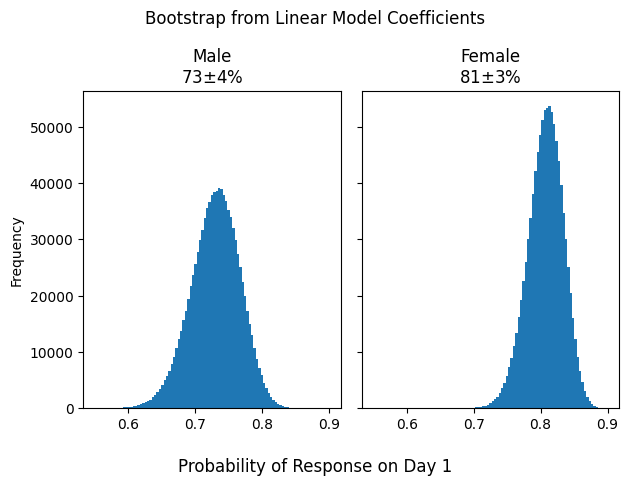

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, sharey=True, sharex=True)
bins = np.linspace(0.55, 0.9, 100)

axes[0].hist(male_probs, bins=bins)
axes[1].hist(female_probs, bins=bins)

axes[0].set_title(
    f"Male\n{100 * np.mean(male_probs):.0f}$\pm${100 * np.std(male_probs):.0f}%"
)
axes[1].set_title(
    f"Female\n{100 * np.mean(female_probs):.0f}$\pm${100 * np.std(female_probs):.0f}%"
)


axes[0].set_ylabel("Frequency")
fig.supxlabel(f"Probability of Response on Day {day}")
fig.suptitle("Bootstrap from Linear Model Coefficients")

fig.tight_layout()
fig.savefig("outputs/imgs/bootstrap_probs.png")

Compliance Rate
----

In [17]:
"""
Make a dataframe holding participant ID, sex and number of entries on each day

"""

from itertools import product


def collapse_meal_info(meal_df: pd.DataFrame, delta: pd.Timedelta) -> pd.DataFrame:
    collapsed_meal_info = pd.DataFrame()

    for _, group in meal_df.groupby("p_id"):
        assert group.index.is_monotonic_increasing

        # Mark which ones are near enough each other to be considered the same
        n_entries = len(group)
        keep = np.ones(n_entries, dtype=bool)

        for i in range(1, n_entries):
            if (group.index[i] - group.index[i - 1] < delta) and (
                group["entry"].iloc[i] == group["entry"].iloc[i - 1]
            ):
                keep[i] = False

        # Append to the new dataframe
        collapsed_meal_info = pd.concat([collapsed_meal_info, group[keep]])

    return collapsed_meal_info


# Read meal info
meal_info = clean.cleaned_smartwatch(keep_catchups=False, keep_day0=False)
meal_info["entry"] = meal_info["meal_type"].isin(
    {"Meal", "Drink", "Snack", "No food/drink"}
)

# Collapse nearby entries
time_cutoff = 27
meal_info = collapse_meal_info(meal_info, pd.Timedelta(minutes=time_cutoff))

In [18]:
compliance_df = pd.DataFrame(
    list(product(meal_info["p_id"].unique(), range(1, 8))), columns=["p_id", "day"]
)
compliance_df["n_entries"] = 0
compliance_df = compliance_df.merge(
    demographic_df[["respondent_sex", "residents_id"]],
    left_on="p_id",
    right_on="residents_id",
    how="left",
)
compliance_df["respondent_sex"] -= 1
compliance_df

,p_id,day,n_entries,respondent_sex,residents_id
0,141,1,0,1.0,141
1,141,2,0,1.0,141
2,141,3,0,1.0,141
3,141,4,0,1.0,141
4,141,5,0,1.0,141
...,...,...,...,...,...
576,39930,3,0,1.0,39930
577,39930,4,0,1.0,39930
578,39930,5,0,1.0,39930
579,39930,6,0,1.0,39930


In [19]:
# Count the number of entries for each participant on each day
for _, row in meal_info.iterrows():
    compliance_df.loc[
        (compliance_df["p_id"] == row["p_id"])
        & (compliance_df["day"] == row["delta"].days),
        "n_entries",
    ] += 1

compliance_df["n_entries"].sum()
compliance_df

,p_id,day,n_entries,respondent_sex,residents_id
0,141,1,12,1.0,141
1,141,2,12,1.0,141
2,141,3,12,1.0,141
3,141,4,12,1.0,141
4,141,5,12,1.0,141
...,...,...,...,...,...
576,39930,3,12,1.0,39930
577,39930,4,12,1.0,39930
578,39930,5,12,1.0,39930
579,39930,6,12,1.0,39930


In [20]:
compliance_df["compliance_rate"] = compliance_df["n_entries"] / 12

In [21]:
compliance_df.to_csv("outputs/data/compliance.csv", index=False)

In [43]:
"""
Run linear model for compliance rate vs day

"""

subprocess.run(["Rscript", "analysis_utils/r/compliance_model.R"], check=True)

Loading required package: Matrix
Warning message:
package ‘Matrix’ was built under R version 4.3.2 
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::expand() masks Matrix::expand()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ tidyr::pack()   masks Matrix::pack()
✖ tidyr::unpack() masks Matrix::unpack()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning messages:
1: package ‘dplyr’ was built under R version 4.3.2 
2: package ‘stringr’ was built under R version 4.3.2 
Learn more about sjPlot with 'browseVignettes("sjPlot")'.

Attaching package: ‘scales’

The following object is masked from ‘packag

CompletedProcess(args=['Rscript', 'analysis_utils/r/compliance_model.R'], returncode=0)

In [44]:
"""
Find the significance of the drop off in compliance rate

"""

# Find the 95% confidence interval and the odds ratio
slope, err = -0.0386, 0.00911
factor = 1.96
odds_ratio = exp(slope)
lower, upper = exp(slope - factor * err), exp(slope + factor * err)

odds_ratio, lower, upper

(0.9621354863803417, 0.9451084463786052, 0.9794692849263823)

In [41]:
"""
Run linear model for compliance rate vs day with sex as a covariate

"""

subprocess.run(["Rscript", "analysis_utils/r/compliance_sex.R"], check=True)

Loading required package: Matrix
Warning message:
package ‘Matrix’ was built under R version 4.3.2 
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::expand() masks Matrix::expand()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ tidyr::pack()   masks Matrix::pack()
✖ tidyr::unpack() masks Matrix::unpack()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning messages:
1: package ‘dplyr’ was built under R version 4.3.2 
2: package ‘stringr’ was built under R version 4.3.2 
Learn more about sjPlot with 'browseVignettes("sjPlot")'.

Attaching package: ‘scales’

The following object is masked from ‘packag

CompletedProcess(args=['Rscript', 'analysis_utils/r/compliance_sex.R'], returncode=0)

In [24]:
# Intercept day sex
coeffs = np.array([0.94201, -0.04868, 0.06715])
errs = np.array([0.05319, 0.01491, 0.06720])
correlations = np.array(
    [
        [1.000, -0.621, -0.792],
        [-0.621, 1.000, 0.492],
        [-0.792, 0.492, 1.000],
    ]
)
covariance = np.outer(errs, errs) * correlations

day = 1

n_boot = 1_000_000
# Generate random intercepts, day coefficients and sex coefficients
bootstrap_samples = multivariate_normal.rvs(mean=coeffs, cov=covariance, size=n_boot)
intercepts = bootstrap_samples[:, 0]
day_coefs = bootstrap_samples[:, 1]
sex_coefs = bootstrap_samples[:, 2]

# Find male and female probabilities for each
male_probs = 1 / (1 + np.exp(-(intercepts + day * day_coefs)))
female_probs = 1 / (1 + np.exp(-(intercepts + sex_coefs + day * day_coefs)))

diff = female_probs - male_probs
print(100 * diff.mean(), 100 * np.percentile(diff, [2.5, 97.5]))

1.3638118938534287 [-1.30690608  4.04235545]


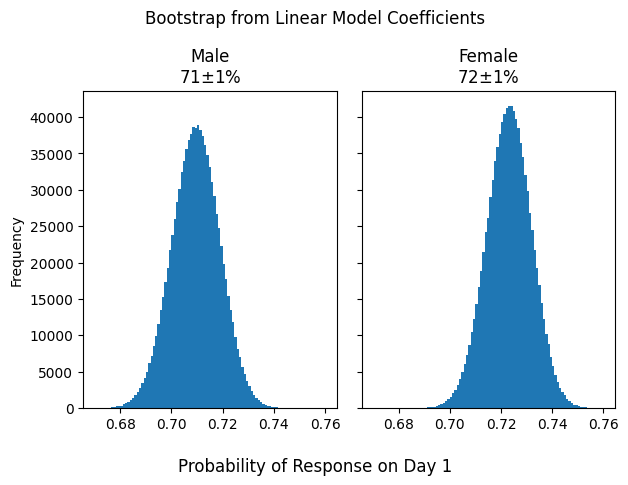

In [25]:
fig, axes = plt.subplots(1, 2, sharey=True, sharex=True)
bins = np.linspace(0.67, 0.76, 100)

axes[0].hist(male_probs, bins=bins)
axes[1].hist(female_probs, bins=bins)


axes[0].set_title(
    f"Male\n{100 * np.mean(male_probs):.0f}$\pm${100 * np.std(male_probs):.0f}%"
)

axes[1].set_title(
    f"Female\n{100 * np.mean(female_probs):.0f}$\pm${100 * np.std(female_probs):.0f}%"
)


axes[0].set_ylabel("Frequency")
fig.supxlabel(f"Probability of Response on Day {day}")
fig.suptitle("Bootstrap from Linear Model Coefficients")

fig.tight_layout()
fig.savefig("outputs/imgs/compliance_bootstrap_probs.png")